# 06 — Dynamic-Graph iTransformer (v3)

## v3 Improvements
- **Cross-battery split** (no data leakage)
- **18 features** per timestep (6 new physics-informed features)

## Architecture
- **iTransformer backbone** with inverted (feature-wise) attention
- **Dynamic Graph Convolution** layer that learns inter-feature adjacency dynamically
- Fuses local (graph) + global (attention) representations
- Built with TensorFlow/Keras

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from src.models.deep.itransformer import build_dynamic_graph_itransformer
from src.evaluation.metrics import regression_metrics, tolerance_accuracy
from src.utils.plotting import save_fig
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE,
    TRANSFORMER_D_MODEL, TRANSFORMER_NHEAD, TRANSFORMER_LAYERS, DROPOUT,
)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
plt.style.use("seaborn-v0_8-whitegrid")

# v3 paths
v3 = get_version_paths('v3')
ensure_version_dirs('v3')

TensorFlow: 2.20.0
GPUs: []


{'root': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3'),
 'models_classical': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/classical'),
 'models_deep': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/deep'),
 'models_ensemble': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/ensemble'),
 'scalers': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/scalers'),
 'figures': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/figures'),
 'results': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/results'),
 'logs': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/logs')}

## 1. Load & Prepare Data

In [2]:
V3_FEATURES = v3["root"] / "features"
data = np.load(str(V3_FEATURES / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

# ── v3 FIX: Cross-battery grouped split ──
unique_bids = np.unique(bids)
rng = np.random.RandomState(42)
shuffled = unique_bids.copy()
rng.shuffle(shuffled)
n_train = max(1, int(len(shuffled) * 0.8))
train_bats = set(shuffled[:n_train])
test_bats = set(shuffled[n_train:])

train_mask = np.isin(bids, list(train_bats))
test_mask = np.isin(bids, list(test_bats))

X_train, y_train = X_multi[train_mask], y_multi[train_mask]
X_test, y_test = X_multi[test_mask], y_multi[test_mask]

from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Overlap: {train_bats & test_bats if train_bats & test_bats else 'NONE ✓'}")

Train: (1444, 32, 18) | Test: (290, 32, 18)
Overlap: NONE ✓


## 2. Build Dynamic-Graph iTransformer

In [3]:
dg_model = build_dynamic_graph_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT,
)
dg_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
dg_model.summary()
print(f"\nTotal parameters: {dg_model.count_params():,}")

Model: "DynamicGraph_iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dyn_graph (DynamicGraphConv)    │ (None, 32, 18)         │           378 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj (Dense)                    │ (None, 32, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_feat_0 (FeatureWiseMHA)      │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_token_0 (TokenWiseMHA)       │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_ff_0 (Conv1DFeedForward)     │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_feat_1 (FeatureWiseMHA)      │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_token_1 (TokenWiseMHA)       │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dg_ff_1 (Conv1DFeedForward)     │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,971 (495.98 KB)

 Trainable params: 126,971 (495.98 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 126,971


## 3. Train

In [4]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10, verbose=1,
    ),
]

history = dg_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1,
)

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"\nBest epoch: {best_epoch}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 3107.6074 - mae: 51.8714 - val_loss: 1967.3826 - val_mae: 42.0192 - learning_rate: 0.0010
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 856.7082 - mae: 24.9853 - val_loss: 379.6254 - val_mae: 16.3422 - learning_rate: 0.0010
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 541.1316 - mae: 16.8246 - val_loss: 404.9633 - val_mae: 16.7222 - learning_rate: 0.0010
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 325.5964 - mae: 13.5706 - val_loss: 277.5700 - val_mae: 11.9630 - learning_rate: 0.0010
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 172.9639 - mae: 9.5096 - val_loss: 276.4447 - val_mae: 12.7127 - learning_rate: 0.0010
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 137.8238 - mae: 8.5541 - val_loss: 198.3174 - val_mae: 11.9075 - learning_rate: 0.0010
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 108.1718 - mae: 7.3416 - val_loss: 192.5336 - val_ma

## 4. Evaluate

In [5]:
y_pred = dg_model.predict(X_test, verbose=0).flatten()
metrics = regression_metrics(y_test, y_pred)
metrics["tol_2pct"] = tolerance_accuracy(y_test, y_pred, 2.0)
metrics["tol_5pct"] = tolerance_accuracy(y_test, y_pred, 5.0)

print("Dynamic-Graph iTransformer Results (v3):")
print(f"  MAE  = {metrics['MAE']:.4f}")
print(f"  RMSE = {metrics['RMSE']:.4f}")
print(f"  R²   = {metrics['R2']:.4f}")
print(f"  MAPE = {metrics['MAPE']:.2f}%")
print(f"  Tol.Acc (±2%) = {metrics['tol_2pct']:.2%}")
print(f"  Tol.Acc (±5%) = {metrics['tol_5pct']:.2%}")

dg_model.save(str(v3["models_deep"] / "dynamic_graph_itransformer.keras"))
print("Model saved.")

Dynamic-Graph iTransformer Results (v3):
  MAE  = 8.7674
  RMSE = 10.3592
  R²   = 0.7090
  MAPE = 23.28%
  Tol.Acc (±2%) = 8.97%
  Tol.Acc (±5%) = 24.14%
Model saved.


## 5. Training Curves

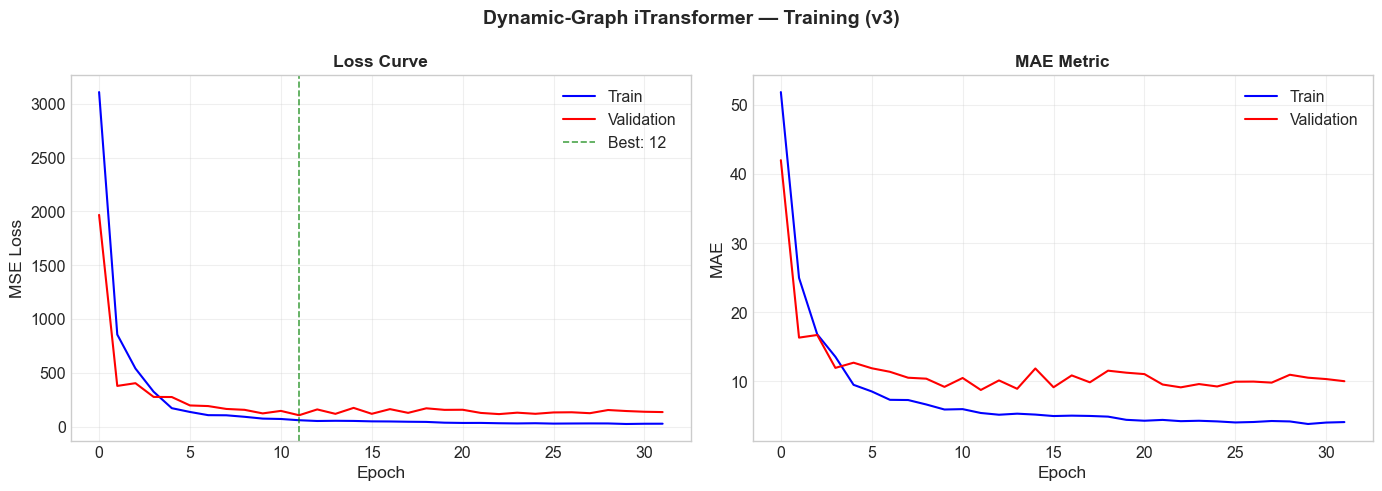

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], "b-", linewidth=1.5, label="Train")
axes[0].plot(history.history["val_loss"], "r-", linewidth=1.5, label="Validation")
axes[0].axvline(x=best_epoch-1, color="green", linestyle="--", alpha=0.7, label=f"Best: {best_epoch}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# MAE
if "mae" in history.history:
    axes[1].plot(history.history["mae"], "b-", linewidth=1.5, label="Train")
    axes[1].plot(history.history["val_mae"], "r-", linewidth=1.5, label="Validation")
    axes[1].set_ylabel("MAE")
else:
    axes[1].plot(history.history["loss"], "b-", linewidth=1.5, label="Train Loss")
    axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_title("MAE Metric", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Dynamic-Graph iTransformer — Training (v3)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v3_dg_itransformer_training", directory=v3["figures"]); plt.show()

## 6. Actual vs Predicted

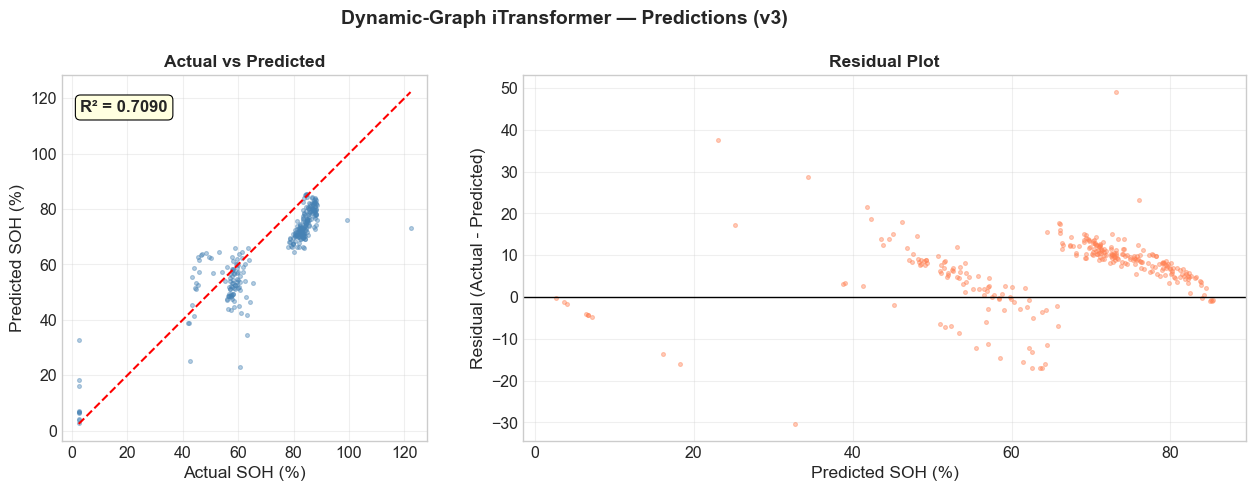

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, s=8, alpha=0.4, c="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].annotate(f"R² = {metrics['R2']:.4f}", xy=(0.05, 0.9), xycoords="axes fraction",
                 fontsize=12, fontweight="bold", bbox=dict(boxstyle="round", facecolor="lightyellow"))
axes[0].set_xlabel("Actual SOH (%)"); axes[0].set_ylabel("Predicted SOH (%)")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, s=8, alpha=0.4, c="coral")
axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted SOH (%)"); axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot", fontweight="bold"); axes[1].grid(True, alpha=0.3)

plt.suptitle("Dynamic-Graph iTransformer — Predictions (v3)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v3_dg_itransformer_predictions", directory=v3["figures"]); plt.show()

## 7. Learned Adjacency Matrix Visualization
Visualizing the learned inter-feature adjacency (if exposed by the model).

In [8]:
# Attempt to extract adjacency matrix from DynamicGraphConv layers
adj_found = False
for layer in dg_model.layers:
    if hasattr(layer, "adj"):
        adj = layer.adj.numpy()
        adj_found = True
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(adj, cmap="viridis", aspect="auto")
        ax.set_xlabel("Feature j"); ax.set_ylabel("Feature i")
        ax.set_title("Learned Dynamic Adjacency Matrix (v3)", fontsize=13, fontweight="bold")
        plt.colorbar(im, ax=ax)
        save_fig(fig, "v3_dg_adjacency_matrix", directory=v3["figures"])
        plt.show()
        break

if not adj_found:
    print("Adjacency matrix not directly accessible; model uses softmax(QK^T) for dynamic graphs.")
    print("Architecture relies on implicit feature correlations via attention.")

# Save metrics
import json
with open(v3["results"] / "v3_dg_itransformer_results.json", "w") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)

# v3: save raw predictions
np.savez_compressed(
    str(v3["results"] / "v3_dg_predictions.npz"),
    y_test=y_test, y_pred=y_pred,
)
print("Results + predictions saved to v3")

Adjacency matrix not directly accessible; model uses softmax(QK^T) for dynamic graphs.
Architecture relies on implicit feature correlations via attention.
Results + predictions saved to v3
